In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.shape

(768, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
x = df.drop(columns=['Outcome'])

In [7]:
zero_as_nan_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
x[zero_as_nan_cols] = x[zero_as_nan_cols].replace(0, np.nan)

In [8]:
x.fillna(x.mean(), inplace=True)

In [9]:
scaler  = StandardScaler()
sc_x = scaler.fit_transform(x)

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(sc_x)

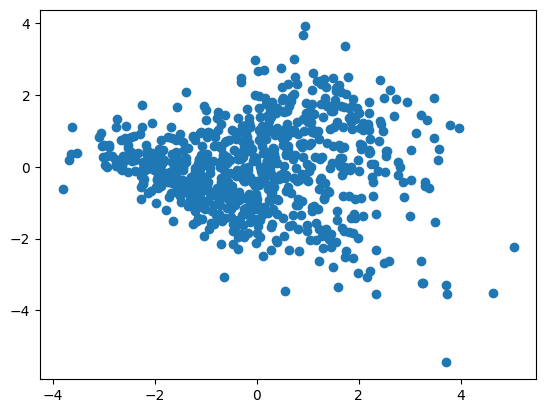

In [11]:
plt.scatter(df_pca[:,0],df_pca[:,1])

In [12]:
from sklearn.metrics import f1_score

best_score = 0
best_contamination = 0.0

# Try different contamination values
for c in np.arange(0.01, 0.1, 0.01):
    iso = IsolationForest(contamination=c, random_state=42)
    preds = iso.fit_predict(df_pca)
    preds = np.where(preds == -1, 1, 0)  # -1 => anomaly => 1

    score = f1_score(df['Outcome'], preds)
    print(f"Contamination: {c:.2f}, F1 Score: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_contamination = c

print(f"\nBest contamination: {best_contamination:.2f}, Best F1 Score: {best_score:.4f}")


Contamination: 0.01, F1 Score: 0.0290
Contamination: 0.02, F1 Score: 0.0634
Contamination: 0.03, F1 Score: 0.0959
Contamination: 0.04, F1 Score: 0.1003
Contamination: 0.05, F1 Score: 0.0977
Contamination: 0.06, F1 Score: 0.1270
Contamination: 0.07, F1 Score: 0.1491
Contamination: 0.08, F1 Score: 0.1636
Contamination: 0.09, F1 Score: 0.1775

Best contamination: 0.09, Best F1 Score: 0.1775


In [43]:
iso = IsolationForest(contamination=0.09,random_state=42)  # contamination=0.1 means 10% of your data will be labeled as anomalies. 

In [44]:
df['anomaly'] = iso.fit_predict(sc_x)

In [45]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,anomaly
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,1
4,0,137,40,35,168,43.1,2.288,33,1,-1
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,-1
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,1
766,1,126,60,0,0,30.1,0.349,47,1,1


In [46]:
z = df.values

In [47]:
index = np.where(df['anomaly'] < 0)
index     # indices where outlier is present

(array([  4,   8,  13,  18,  28,  39,  43,  45,  53,  57,  84,  92,  99,
        120, 125, 153, 159, 177, 186, 187, 206, 220, 228, 231, 245, 247,
        254, 258, 270, 286, 294, 303, 323, 362, 370, 375, 379, 409, 440,
        445, 453, 458, 459, 486, 487, 489, 519, 537, 549, 579, 582, 584,
        590, 593, 597, 606, 612, 622, 655, 661, 662, 672, 673, 691, 695,
        715, 744, 747, 753, 763]),)

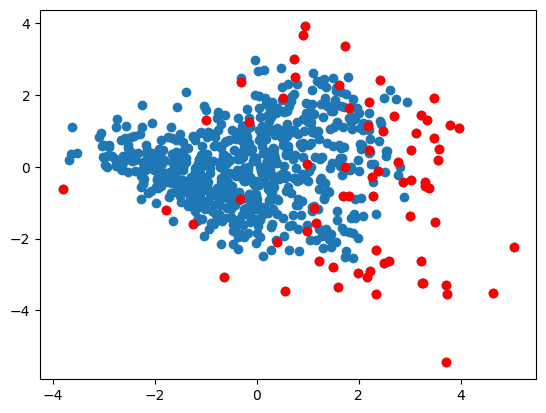

In [48]:
plt.scatter(df_pca[:,0],df_pca[:,1],label='Normal Data')
plt.scatter(df_pca[index,0],df_pca[index,1],color='red',label='Anomalies')